# Parameter-to-POD-coefficient surrogate validation

This notebook validates the online prediction stage of a reduced-order model.

The workflow is:

1. Generate training and unseen test snapshots.
2. Construct a POD basis using only the training snapshots.
3. Project the training snapshots onto the reduced basis.
4. Learn the mapping from parameter values to POD coefficients.
5. Predict coefficients for unseen parameter values.
6. Reconstruct the corresponding full-order fields.
7. Compare projection error with surrogate prediction error.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# This works whether the kernel starts in the repository root
# or inside the notebooks folder.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Working directory: /Users/rallen/Documents/msc-rom-particle-systems
Project root: /Users/rallen/Documents/msc-rom-particle-systems
Figure directory: /Users/rallen/Documents/msc-rom-particle-systems/results/figures


In [2]:
def full_order_solution(
    x: np.ndarray,
    mu: float,
) -> np.ndarray:
    """Generate the parameterised full-order spatial field."""
    return (
        np.sin(np.pi * x)
        + mu * np.sin(2.0 * np.pi * x)
        + mu**2 * np.cos(3.0 * np.pi * x)
    )


n_space = 200
x = np.linspace(0.0, 1.0, n_space)

In [3]:
# Training parameters are spaced every 0.1.
train_parameters = np.linspace(0.0, 2.0, 21)

# Test parameters lie halfway between training parameters,
# so none appeared in the training data.
test_parameters = (
    train_parameters[:-1]
    + np.diff(train_parameters) / 2.0
)

train_snapshots = np.column_stack(
    [
        full_order_solution(x, mu)
        for mu in train_parameters
    ]
)

test_snapshots = np.column_stack(
    [
        full_order_solution(x, mu)
        for mu in test_parameters
    ]
)

print("Training parameters:", train_parameters.shape)
print("Test parameters:", test_parameters.shape)
print("Training snapshot matrix:", train_snapshots.shape)
print("Test snapshot matrix:", test_snapshots.shape)

overlap = np.intersect1d(train_parameters, test_parameters)
print("Overlapping parameter values:", overlap)

Training parameters: (21,)
Test parameters: (20,)
Training snapshot matrix: (200, 21)
Test snapshot matrix: (200, 20)
Overlapping parameter values: []


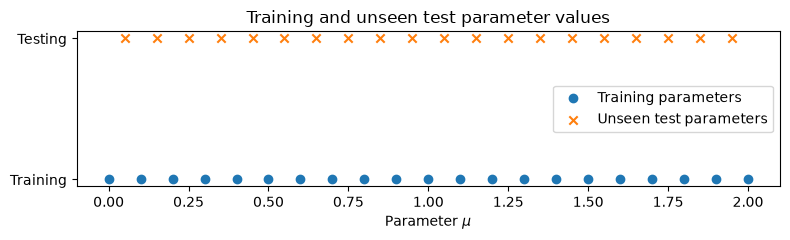

In [4]:
plt.figure(figsize=(8, 2.5))

plt.scatter(
    train_parameters,
    np.zeros_like(train_parameters),
    marker="o",
    label="Training parameters",
)

plt.scatter(
    test_parameters,
    np.ones_like(test_parameters),
    marker="x",
    label="Unseen test parameters",
)

plt.yticks([0, 1], ["Training", "Testing"])
plt.xlabel(r"Parameter $\mu$")
plt.title("Training and unseen test parameter values")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "toy_parameter_split.pdf",
    bbox_inches="tight",
)

plt.show()

In [5]:
U_train, singular_values, Vt_train = np.linalg.svd(
    train_snapshots,
    full_matrices=False,
)

rank = 3
pod_basis = U_train[:, :rank]

# Reduced coefficients for training snapshots.
train_coefficients = pod_basis.T @ train_snapshots

print("POD basis shape:", pod_basis.shape)
print("Training coefficient matrix:", train_coefficients.shape)
print("First three singular values:")
print(singular_values[:3])

POD basis shape: (200, 3)
Training coefficient matrix: (3, 21)
First three singular values:
[82.64581665 29.3610013   6.74911325]


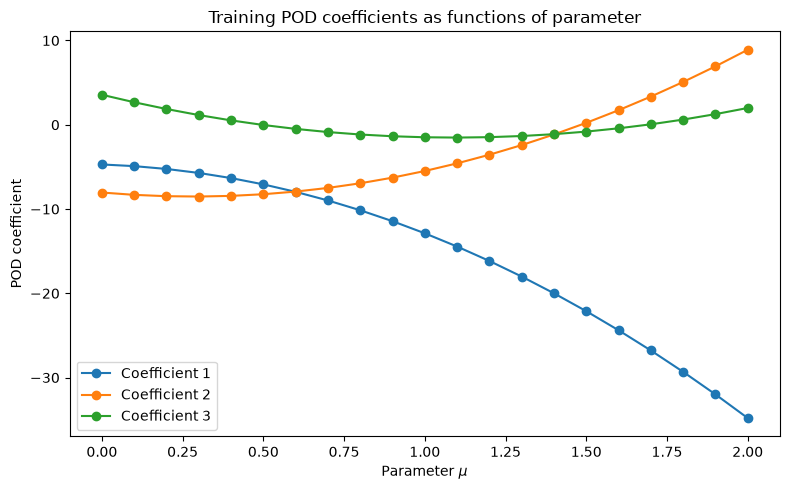

In [6]:
plt.figure(figsize=(8, 5))

for mode_index in range(rank):
    plt.plot(
        train_parameters,
        train_coefficients[mode_index, :],
        marker="o",
        label=f"Coefficient {mode_index + 1}",
    )

plt.xlabel(r"Parameter $\mu$")
plt.ylabel("POD coefficient")
plt.title("Training POD coefficients as functions of parameter")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "toy_training_coefficients.pdf",
    bbox_inches="tight",
)

plt.show()

In [7]:
polynomial_features = PolynomialFeatures(
    degree=2,
    include_bias=True,
)

train_inputs = polynomial_features.fit_transform(
    train_parameters.reshape(-1, 1)
)

test_inputs = polynomial_features.transform(
    test_parameters.reshape(-1, 1)
)

surrogate = LinearRegression(fit_intercept=False)

# scikit-learn expects one sample per row:
# shape (n_training_parameters, n_coefficients).
surrogate.fit(
    train_inputs,
    train_coefficients.T,
)

predicted_test_coefficients = surrogate.predict(
    test_inputs
).T

print(
    "Predicted test coefficient matrix:",
    predicted_test_coefficients.shape,
)

Predicted test coefficient matrix: (3, 20)


In [8]:
predicted_test_snapshots = (
    pod_basis @ predicted_test_coefficients
)

# Best possible reconstructions using this POD basis.
projected_test_coefficients = pod_basis.T @ test_snapshots
projected_test_snapshots = (
    pod_basis @ projected_test_coefficients
)

print(
    "Predicted test snapshots:",
    predicted_test_snapshots.shape,
)

Predicted test snapshots: (200, 20)


In [9]:
def columnwise_relative_error(
    reference: np.ndarray,
    approximation: np.ndarray,
) -> np.ndarray:
    """Calculate one relative L2 error for each snapshot column."""
    numerator = np.linalg.norm(
        reference - approximation,
        axis=0,
    )
    denominator = np.linalg.norm(reference, axis=0)

    return numerator / denominator


projection_errors = columnwise_relative_error(
    test_snapshots,
    projected_test_snapshots,
)

surrogate_errors = columnwise_relative_error(
    test_snapshots,
    predicted_test_snapshots,
)

print(
    "Mean projection error:",
    f"{projection_errors.mean():.3e}",
)

print(
    "Mean surrogate error:",
    f"{surrogate_errors.mean():.3e}",
)

print(
    "Maximum surrogate error:",
    f"{surrogate_errors.max():.3e}",
)

Mean projection error: 6.394e-16
Mean surrogate error: 5.324e-16
Maximum surrogate error: 1.021e-15


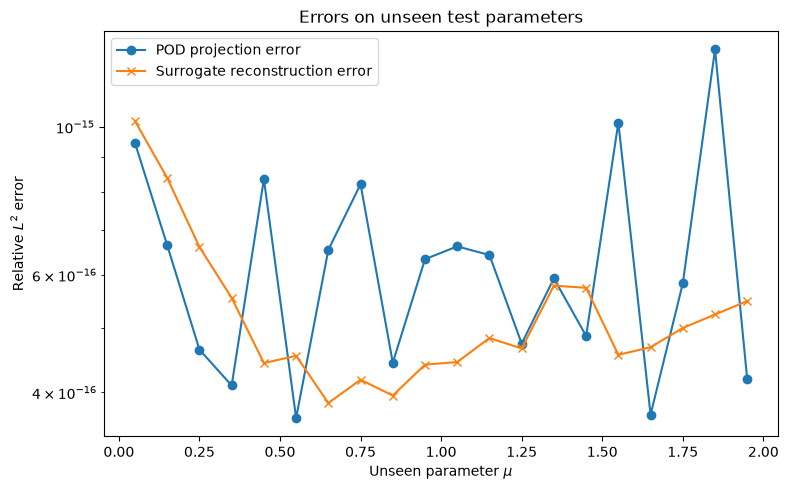

In [10]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    test_parameters,
    projection_errors,
    marker="o",
    label="POD projection error",
)

plt.semilogy(
    test_parameters,
    surrogate_errors,
    marker="x",
    label="Surrogate reconstruction error",
)

plt.xlabel(r"Unseen parameter $\mu$")
plt.ylabel("Relative $L^2$ error")
plt.title("Errors on unseen test parameters")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "toy_surrogate_test_errors.pdf",
    bbox_inches="tight",
)

plt.show()

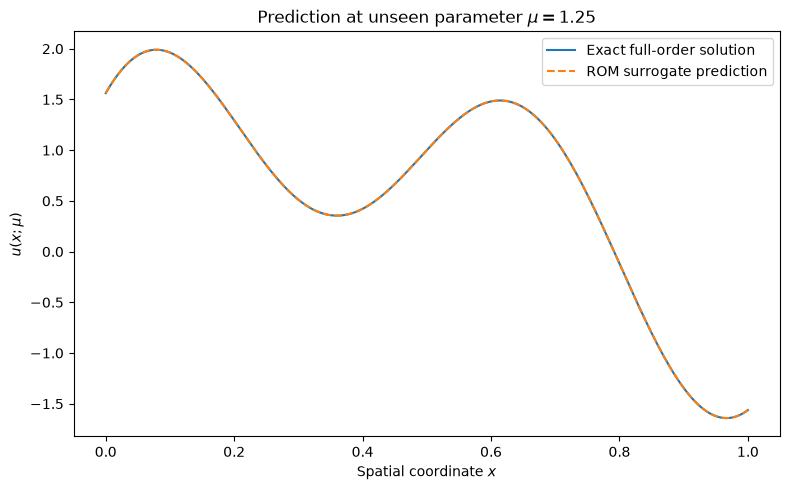

In [11]:
test_index = 12
mu_test = test_parameters[test_index]

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    test_snapshots[:, test_index],
    label="Exact full-order solution",
)

plt.plot(
    x,
    predicted_test_snapshots[:, test_index],
    linestyle="--",
    label="ROM surrogate prediction",
)

plt.xlabel("Spatial coordinate $x$")
plt.ylabel(r"$u(x;\mu)$")
plt.title(
    rf"Prediction at unseen parameter $\mu={mu_test:.2f}$"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "toy_unseen_snapshot_prediction.pdf",
    bbox_inches="tight",
)

plt.show()

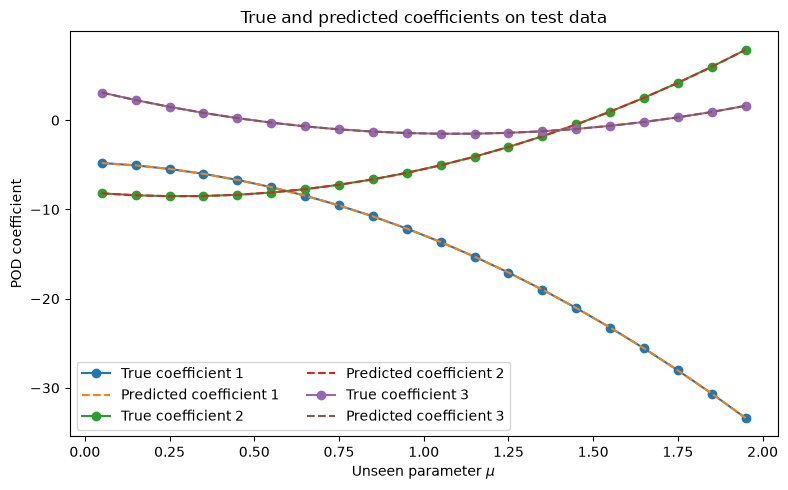

In [12]:
plt.figure(figsize=(8, 5))

for mode_index in range(rank):
    plt.plot(
        test_parameters,
        projected_test_coefficients[mode_index, :],
        marker="o",
        label=f"True coefficient {mode_index + 1}",
    )

    plt.plot(
        test_parameters,
        predicted_test_coefficients[mode_index, :],
        linestyle="--",
        label=f"Predicted coefficient {mode_index + 1}",
    )

plt.xlabel(r"Unseen parameter $\mu$")
plt.ylabel("POD coefficient")
plt.title("True and predicted coefficients on test data")
plt.legend(ncol=2)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "toy_predicted_coefficients.pdf",
    bbox_inches="tight",
)

plt.show()

## Interpretation

The POD basis was constructed using only the training snapshots, while the
test parameters were placed between the training parameter values and were
therefore unseen during model construction.

A rank-three basis represents the solution space to machine precision. The
degree-two polynomial surrogate also reproduces the dependence of the POD
coefficients on the parameter accurately because the original full-order
solution depends quadratically on the parameter.

Both the mean POD projection error and the mean surrogate reconstruction
error are approximately $10^{−15}$, indicating that the remaining
differences are due to floating-point round-off rather than model error.

This validates the full non-intrusive reduced-order modelling workflow:
$$
\mu
\longrightarrow
\text{predicted reduced coefficients}
\longrightarrow
\text{reconstructed full-order field}.
$$
For real particle-system data, the parameter-to-coefficient relationship will
not generally be exactly polynomial. The surrogate error will therefore be
nonzero and should be separated from the POD projection error.